In [1]:

!pip install -q transformers datasets accelerate scikit-learn underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 57.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.6/978.6 kB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 113.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 43.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:

import os
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from datasets import Dataset, DatasetDict
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)

# Tắt WandB để không bị hỏi đăng nhập gây treo code
os.environ["WANDB_DISABLED"] = "true"

# Kiểm tra GPU
print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

2025-12-17 04:18:11.885757: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765945092.080181      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765945092.134922      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

GPU Available: True
Device: Tesla T4


In [3]:


# Định nghĩa từ điển thay thế Emoji/Acronyms theo mô tả
REPLACE_DICT = {
    ":)": "colonsmile",
    ":(": "colonsad",
    "@@": "colonsurprise",
    "<3": "colonlove",
    ":d": "colonsmilesmile",
    ":3": "coloncontemn",
    ":v": "colonbigsmile",
    ":_": "coloncc",
    ":p": "colonsmallsmile",
    ">>": "coloncolon",
    ":\">": "colonlovelove",
    "^^": "colonhihi",
    ":": "doubledot",
    ":'(": "colonsadcolon",
    ":’(": "colonsadcolon",
    ":@": "colondoublesurprise",
    "v.v": "vdotv",
    "...": "dotdotdot",
    "/": "fraction",
    "c#": "cshrap"
}

def normalize_text(text):
    """Thay thế các emoji/ký tự đặc biệt bằng từ khóa"""
    text = text.lower() # Chuyển về chữ thường trước khi replace
    for k, v in REPLACE_DICT.items():
        # Dùng replace đơn giản, có thể nâng cấp bằng regex nếu cần chính xác từ biên
        text = text.replace(k, f" {v} ") 
    # Xóa khoảng trắng thừa
    return " ".join(text.split())

def load_data_from_dir(data_dir):
    sents_path = os.path.join(data_dir, "sents.txt")
    sentiments_path = os.path.join(data_dir, "sentiments.txt")
    
    if not os.path.exists(sents_path) or not os.path.exists(sentiments_path):
        raise FileNotFoundError(f"Missing sents.txt or sentiments.txt in {data_dir}")
        
    with open(sents_path, "r", encoding="utf-8") as f:
        # Áp dụng normalize_text ngay khi đọc
        sents = [normalize_text(line.strip()) for line in f.readlines()]
        
    with open(sentiments_path, "r", encoding="utf-8") as f:
        labels = [int(line.strip()) for line in f.readlines()]
        
    return {"text": sents, "label": labels}

def load_uit_vsfc_dataset(base_path):
    data = {}
    for split in ["train", "dev", "test"]:
        split_dir = os.path.join(base_path, split)
        print(f"Loading {split} from {split_dir}...")
        data[split] = Dataset.from_dict(load_data_from_dir(split_dir))
    return DatasetDict(data)

# ĐƯỜNG DẪN DỮ LIỆU CỦA BẠN (Sửa lại đúng path trên Kaggle của bạn)
DATA_DIR = "/kaggle/input/linh1234/UIT-VSFC" 
# DATA_DIR = "/kaggle/input/uit-vsfc/UIT-VSFC" # Ví dụ path khác

try:
    dataset = load_uit_vsfc_dataset(DATA_DIR)
    print("\nCheck chuẩn hóa text:")
    print("Gốc (đã normalize):", dataset["train"][0]['text'])
except FileNotFoundError:
    print("Vui lòng kiểm tra lại đường dẫn DATA_DIR")

Loading train from /kaggle/input/linh1234/UIT-VSFC/train...
Loading dev from /kaggle/input/linh1234/UIT-VSFC/dev...
Loading test from /kaggle/input/linh1234/UIT-VSFC/test...

Check chuẩn hóa text:
Gốc (đã normalize): slide giáo trình đầy đủ .


In [4]:


try:
    from underthesea import word_tokenize
    HAS_UNDERTHESEA = True
except ImportError:
    HAS_UNDERTHESEA = False

def segment_text(example):
    if HAS_UNDERTHESEA:
        example["text"] = word_tokenize(example["text"], format="text")
    return example

if HAS_UNDERTHESEA:
    print("Segmenting text with underthesea...")
    dataset = dataset.map(segment_text, num_proc=4)
    print("Sample after segmentation:", dataset["train"][0]['text'])

Segmenting text with underthesea...


Map (num_proc=4):   0%|          | 0/11426 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/1583 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/3166 [00:00<?, ? examples/s]

Sample after segmentation: slide giáo_trình đầy_đủ .


In [5]:


MODEL_NAME = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    # CHIẾN LƯỢC MỚI: Max length = 64
    return tokenizer(examples["text"], truncation=True, padding=False, max_length=64)

print("Tokenizing data with max_length=64...")
# Lưu ý: Không chạy oversample_data nữa
tokenized_datasets = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing data with max_length=64...


Map:   0%|          | 0/11426 [00:00<?, ? examples/s]

Map:   0%|          | 0/1583 [00:00<?, ? examples/s]

Map:   0%|          | 0/3166 [00:00<?, ? examples/s]

In [6]:
from torch import nn
from torch.nn import functional as F
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback
from sklearn.metrics import f1_score, recall_score, precision_score

# 1. Focal Loss (Giữ nguyên vì đang hoạt động tốt)
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        else:
            return focal_loss.sum()

# 2. Trainer (Giữ nguyên logic tính Loss)
class FocalLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        device = labels.device 
        
        # Tỷ lệ trọng số: Vẫn ưu tiên Neutral gấp 10 lần
        class_weights = torch.tensor([1.0, 10.0, 1.0]).to(device)
        
        # Gamma=2.5 để tập trung vào ca khó
        loss_fct = FocalLoss(alpha=class_weights, gamma=2.5)
        
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

# 3. Metric TÙY CHỈNH (Quan trọng nhất cho yêu cầu của bạn)
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    # Tính riêng F1 cho từng nhãn
    # labels=[0, 1, 2] -> f1_scores sẽ là mảng [f1_neg, f1_neu, f1_pos]
    f1_scores = f1_score(labels, predictions, average=None)
    
    # Lấy F1 của Neutral (index 1)
    f1_neutral = f1_scores[1] if len(f1_scores) > 1 else 0.0
    
    # Vẫn tính thêm Macro để tham khảo
    macro_f1 = f1_score(labels, predictions, average='macro')
    
    return {
        'eval_f1_macro': macro_f1,
        'eval_f1_neutral': f1_neutral, # KEY NÀY SẼ DÙNG ĐỂ EARLY STOPPING
    }

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

# 4. Training Arguments (CẤU HÌNH CHO 2x T4)
training_args = TrainingArguments(
    output_dir="./results_sentiment_neutral_focus",
    learning_rate=2e-5,
    
    # --- CẤU HÌNH GPU MẠNH ---
    per_device_train_batch_size=64, # Tăng lên 64 (2 GPU = 128 mẫu/step) -> Train cực nhanh
    per_device_eval_batch_size=64,
    fp16=True,                      # Bật Mixed Precision (Tăng tốc độ trên T4)
    dataloader_num_workers=4,       # Tăng tốc độ nạp dữ liệu vào GPU
    # -------------------------
    
    num_train_epochs=15,            # Set dư ra, Early Stop sẽ tự cắt
    weight_decay=0.02,              # Chống overfitting
    
    eval_strategy="epoch",
    save_strategy="epoch",
    
    # --- CẤU HÌNH EARLY STOPPING MỚI ---
    load_best_model_at_end=True,
    
    # Chỉ quan tâm đến F1 Neutral
    metric_for_best_model="eval_f1_neutral", 
    greater_is_better=True, # F1 càng cao càng tốt
    # -----------------------------------
    
    report_to="none",
    save_total_limit=2
)

# 5. Khởi tạo Trainer
trainer = FocalLossTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["dev"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    
    # Nếu F1 Neutral không tăng trong 3 epoch liên tiếp -> DỪNG
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_47/3804154900.py:94: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `FocalLossTrainer.__init__`. Use `processing_class` instead.
  trainer = FocalLossTrainer(


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

In [7]:

print("Bắt đầu train ")
trainer.train()

Bắt đầu train 


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Neutral
1,No log,0.393290,0.827011,0.575000
2,No log,0.284293,0.825409,0.572864
3,No log,0.291695,0.823507,0.562162
4,No log,0.363316,0.868028,0.675497
5,No log,0.419263,0.862735,0.662252
6,0.218100,0.538390,0.851879,0.629371
7,0.218100,0.507899,0.853408,0.635135


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked t

TrainOutput(global_step=630, training_loss=0.1883883415706574, metrics={'train_runtime': 445.6424, 'train_samples_per_second': 384.591, 'train_steps_per_second': 3.029, 'total_flos': 2189187914013576.0, 'train_loss': 0.1883883415706574, 'epoch': 7.0})

Đang chạy Threshold Tuning trên tập DEV...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



>>> TÌM THẤY NGƯỠNG TỐI ƯU (NEUTRAL): 0.40
>>> Best Macro F1 trên DEV: 0.8675

ĐÁNH GIÁ TRÊN TẬP TEST VỚI THRESHOLD 0.40


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


                precision    recall  f1-score   support

  Tiêu cực (0)     0.9517    0.9517    0.9517      1409
Trung tính (1)     0.5819    0.6168    0.5988       167
  Tích cực (2)     0.9538    0.9478    0.9508      1590

      accuracy                         0.9321      3166
     macro avg     0.8292    0.8388    0.8338      3166
  weighted avg     0.9333    0.9321    0.9326      3166



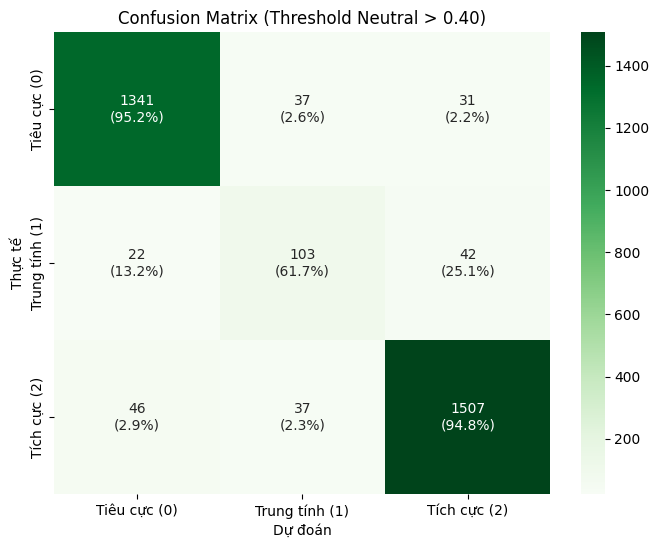

In [8]:
# cell 8: đánh giá tổng quan model ở nhiều khía cạnh 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import torch.nn.functional as F

print("Đang chạy Threshold Tuning trên tập DEV...")

# 1. Lấy xác suất dự đoán (Probabilities) trên tập DEV
# Lưu ý: Phải dùng tập DEV để tìm ngưỡng, không dùng tập TEST (để tránh data leakage)
raw_pred_dev, labels_dev, _ = trainer.predict(tokenized_datasets["dev"])
# Chuyển logits thành xác suất (Softmax)
probs_dev = torch.nn.functional.softmax(torch.tensor(raw_pred_dev), dim=-1).numpy()

# 2. Hàm dự đoán với ngưỡng tùy chỉnh cho Neutral
def predict_with_threshold(probs, threshold_neutral):
    # probs: [n_samples, 3]
    preds = []
    for p in probs:
        # Nếu xác suất nhãn Neutral (index 1) > ngưỡng -> Chọn Neutral
        if p[1] > threshold_neutral:
            preds.append(1)
        else:
            # Nếu không, chọn nhãn có xác suất cao nhất trong 2 nhãn còn lại (0 và 2)
            # Tạo bản sao để không sửa dữ liệu gốc
            p_copy = p.copy()
            p_copy[1] = -1 # Gán Neutral cực thấp để argmax không chọn nó
            preds.append(np.argmax(p_copy))
    return np.array(preds)

# 3. Dò tìm ngưỡng tốt nhất (Grid Search)
best_threshold = 0.2
best_f1_macro = 0.0
thresholds = np.arange(0.1, 0.95, 0.05) # Thử từ 0.1 đến 0.9

history_thresh = []

for t in thresholds:
    y_pred_t = predict_with_threshold(probs_dev, t)
    # Tính Macro F1
    f1 = f1_score(labels_dev, y_pred_t, average='macro')
    history_thresh.append((t, f1))
    
    if f1 > best_f1_macro:
        best_f1_macro = f1
        best_threshold = t

print(f"\n>>> TÌM THẤY NGƯỠNG TỐI ƯU (NEUTRAL): {best_threshold:.2f}")
print(f">>> Best Macro F1 trên DEV: {best_f1_macro:.4f}")


# best_threshold = 0.3

# 4. Áp dụng ngưỡng tối ưu vào tập TEST
print("\n" + "="*40)
print(f"ĐÁNH GIÁ TRÊN TẬP TEST VỚI THRESHOLD {best_threshold:.2f}")
print("="*40)

raw_pred_test, labels_test, _ = trainer.predict(tokenized_datasets["test"])
probs_test = torch.nn.functional.softmax(torch.tensor(raw_pred_test), dim=-1).numpy()

# Dùng ngưỡng vừa tìm được để dự đoán Test
final_preds_test = predict_with_threshold(probs_test, best_threshold)

# 5. Báo cáo kết quả cuối cùng
target_names = ["Tiêu cực (0)", "Trung tính (1)", "Tích cực (2)"]
print(classification_report(labels_test, final_preds_test, target_names=target_names, digits=4))

# Vẽ Ma trận nhầm lẫn
cm = confusion_matrix(labels_test, final_preds_test)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annot_labels = [f"{count}\n({pct:.1%})" for count, pct in zip(cm.flatten(), cm_norm.flatten())]
annot_labels = np.asarray(annot_labels).reshape(3, 3)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=annot_labels, fmt='', cmap='Greens', 
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Confusion Matrix (Threshold Neutral > {best_threshold:.2f})')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

In [9]:
import pandas as pd
import torch.nn.functional as F

# 1. Chuẩn bị dữ liệu và Dự đoán
print("Đang tổng hợp dữ liệu kiểm thử...")
# Lấy text gốc để dễ đọc (thay vì token ID)
texts = dataset["test"]["text"] 

# Lấy dự đoán từ Trainer
raw_pred_test, label_ids, _ = trainer.predict(tokenized_datasets["test"])
probs_test = F.softmax(torch.tensor(raw_pred_test), dim=-1).numpy()

# Sử dụng Threshold tối ưu (nếu biến best_threshold chưa có thì mặc định 0.5)
current_threshold = best_threshold if 'best_threshold' in globals() else 0.5
print(f"Đang sử dụng ngưỡng Neutral > {current_threshold:.2f} để dự đoán.")

# Hàm áp dụng threshold (như cell trước)
def apply_threshold(probs, thresh):
    preds = []
    for p in probs:
        if p[1] > thresh:
            preds.append(1) # Chọn Neutral
        else:
            p_copy = p.copy()
            p_copy[1] = -1
            preds.append(np.argmax(p_copy)) # Chọn max của Neg/Pos
    return preds

final_preds = apply_threshold(probs_test, current_threshold)

# 2. Tạo DataFrame kết quả
# Map số sang chữ cho dễ đọc
label_map = {0: "Tiêu cực", 1: "Trung tính", 2: "Tích cực"}
# Map từ tiếng Anh (bạn hay dùng) sang tiếng Việt để khớp dữ liệu
query_map = {
    "negative": "Tiêu cực", "neg": "Tiêu cực",
    "neutral": "Trung tính", "neu": "Trung tính",
    "positive": "Tích cực", "pos": "Tích cực"
}

df_results = pd.DataFrame({
    "Nội dung feedback": texts,
    "Nhãn thực tế": [label_map[l] for l in label_ids],
    "Nhãn dự đoán": [label_map[l] for l in final_preds],
    "Prob_Neg": probs_test[:, 0],
    "Prob_Neu": probs_test[:, 1],
    "Prob_Pos": probs_test[:, 2]
})

# 3. Hàm Tra cứu theo yêu cầu của bạn
def tra_cuu(thuc_te=None, du_doan=None, so_luong=10):
    """
    Hàm lọc các câu theo nhãn thực tế và dự đoán.
    Input nhận tiếng Anh (neutral, positive...) hoặc tiếng Việt.
    """
    temp_df = df_results.copy()
    
    # Lọc theo nhãn thực tế (nếu có yêu cầu)
    if thuc_te:
        thuc_te_clean = query_map.get(thuc_te.lower(), thuc_te) # Chẩn hóa input
        temp_df = temp_df[temp_df["Nhãn thực tế"] == thuc_te_clean]
        
    # Lọc theo nhãn dự đoán (nếu có yêu cầu)
    if du_doan:
        du_doan_clean = query_map.get(du_doan.lower(), du_doan) # Chuẩn hóa input
        temp_df = temp_df[temp_df["Nhãn dự đoán"] == du_doan_clean]
    
    print(f"--> Tìm thấy {len(temp_df)} câu khớp yêu cầu.")
    
    # Hiển thị bảng
    if len(temp_df) > 0:
        pd.set_option('display.max_colwidth', None) # Để hiển thị full câu dài
        display(temp_df[["Nội dung feedback", "Nhãn thực tế", "Nhãn dự đoán"]].head(so_luong))
    else:
        print("Không có kết quả nào!")

print("Đã xong! Hãy dùng hàm tra_cuu(thuc_te='...', du_doan='...')")

Đang tổng hợp dữ liệu kiểm thử...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Đang sử dụng ngưỡng Neutral > 0.40 để dự đoán.
Đã xong! Hãy dùng hàm tra_cuu(thuc_te='...', du_doan='...')


In [12]:
tra_cuu(thuc_te="negative", du_doan="positive", so_luong=5)

# negative : 0
# neutral : 1
# positive : 2

--> Tìm thấy 31 câu khớp yêu cầu.


,Nội dung feedback,Nhãn thực tế,Nhãn dự đoán
34,giữa lý_thuyết từ vựng với trò_chơi để dễ tiếp_thu .,Tiêu cực,Tích cực
67,"thêm hoạt_động của sinh_viên , giúp sinh_viên chủ_động hơn .",Tiêu cực,Tích cực
347,thầy dạy dễ hiểu tuy_nhiên nhiều lúc hơi nhanh .,Tiêu cực,Tích cực
364,"cô cho tài_liệu học_tập là một trang_web , lên đó tự học và làm đồ_án .",Tiêu cực,Tích cực
436,làm bài giảng sinh_động .,Tiêu cực,Tích cực


In [14]:
!zip -r /kaggle/working/results_sentiment_neutral_focus.zip /kaggle/working/results_sentiment_neutral_focus


  adding: kaggle/working/results_sentiment_neutral_focus/ (stored 0%)
  adding: kaggle/working/results_sentiment_neutral_focus/checkpoint-630/ (stored 0%)
  adding: kaggle/working/results_sentiment_neutral_focus/checkpoint-630/optimizer.pt (deflated 39%)
  adding: kaggle/working/results_sentiment_neutral_focus/checkpoint-630/special_tokens_map.json (deflated 57%)
  adding: kaggle/working/results_sentiment_neutral_focus/checkpoint-630/scheduler.pt (deflated 55%)
  adding: kaggle/working/results_sentiment_neutral_focus/checkpoint-630/trainer_state.json (deflated 71%)
  adding: kaggle/working/results_sentiment_neutral_focus/checkpoint-630/scaler.pt (deflated 60%)
  adding: kaggle/working/results_sentiment_neutral_focus/checkpoint-630/model.safetensors (deflated 16%)
  adding: kaggle/working/results_sentiment_neutral_focus/checkpoint-630/rng_state.pth (deflated 25%)
  adding: kaggle/working/results_sentiment_neutral_focus/checkpoint-630/added_tokens.json (stored 0%)
  adding: kaggle/workin